# Research Proposal: Modeling Daily Parking Ticket Counts in Milwaukee

### John Eckberg

## Overview
[Milwaukee plans 65,000 more parking tickets, longer meter hours to fill transportation budget gap](https://www.jsonline.com/story/news/local/milwaukee/2025/10/21/milwaukee-aims-for-550k-parking-tickets-longer-meter-hours-in-2026/86817755007/) The city of Milwaukee relies on parking ticket revenue in order to fill budget gaps, a pressing issue given the [current deficit](https://urbanmilwaukee.com/2025/03/12/mke-county-county-faces-47-million-2026-budget-deficit/) the county is facing.
This project plans to examine how daily parking ticket activity in Milwaukee varies across time and environmental conditions. Using parking citation records obtained through a Freedom of Information Act request (2014–2022), I propose to model daily ticket counts and evaluate whether temporal, weather, and holiday-related factors explain variation in enforcement volume.

## Research Question
What is the daily rate of parking tickets issued in Milwaukee, and which factors most strongly influence that rate (if any)? In particular, I propose to test whether day of week, month/seasonality, holidays, and precipitation are associated with higher or lower daily ticket counts, including by citation type.

## Hypothesis
- Null Hypothesis: day of week, month/seasonality, holidays, and precipitation do not affect daily ticket counts.
- Alternative Hypothesis: at least one temporal or environmental factor affects daily ticket counts.

## Data Sources
- **Parking citations:** Milwaukee parking ticket records, initially loaded for 2014, with fields including `ISSUENO`, `ISSUEDATE`, `LOCATIONDESC1`, and `VIODESCRIPTION`.
- **Holiday data:** U.S. holiday dates (2004–2021) pulled from Kaggle to identify atypical traffic/parking demand days.
- **Weather data:** Open-Meteo daily weather for Milwaukee, including maximum temperature, minimum temperature, precipitation, and snowfall.


## Method
The analysis would likely focus on a geographically meaningful subset of Milwaukee (e.g., downtown, Lower East Side, Deer District). Because the response variable is a daily count, I propose that the initial model choice would be a Poisson regression GLM.

### Currently Planned Features
- **Calendar effects:** day of week, month, weekend indicator, and potential seasonal terms.
- **Cyclical time encoding:** sine/cosine transforms for month and day-of-week to preserve circular structure.
- **Holiday effects:** binary `is_holiday` indicator, one-hot encoding for major holiday names.
- **Weather exposure:** `max_temp`, `min_temp`, `precipitation`, and `snowfall`; optional threshold features (e.g., heavy precipitation day).
- **Autocorrelation:** lagged ticket count features (e.g., 1-day and 7-day lags) and short rolling averages.



In [1]:
import pandas as pd
import requests
import kagglehub 
import openpyxl
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

c:\Users\mathewsj\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Loading in the parking data [All Years now]  --  Runs in about 10 mins

#tickets_df = pd.read_excel("data/tickets_csv/2014_parking_citations_issued_open_records_request.xlsx")
data_dir = Path("data/tickets_csv")

tickets_dfs = []

for file in sorted(data_dir.glob("*.xlsx")):
    df = pd.read_excel(file)
    tickets_dfs.append(df)

tickets = pd.concat(tickets_dfs, ignore_index=True)

tickets.sample(5)

,ISSUENO,ISSUEDATE,LOCATIONDESC1,VIODESCRIPTION
3223645,114880975,2019-04-22,3536 N 48TH ST,NIGHT PARKING
2915725,111554903,2018-09-30,5025 W BLUE MOUND RD,PARKING PROHIBITED BY OFFICIAL SIGN
3430372,116875905,2019-09-04,2638 N STOWELL AV,NIGHT PARKING
457912,479747203,2014-09-23,455 E PLEASANT ST,NIGHT PARKING
4427076,127333102,2022-01-28,3075 S 32ND ST,NIGHT PARKING


In [3]:
tickets.info()

<class 'pandas.DataFrame'>
RangeIndex: 4865096 entries, 0 to 4865095
Data columns (total 4 columns):
 #   Column          Dtype         
---  ------          -----         
 0   ISSUENO         int64         
 1   ISSUEDATE       datetime64[us]
 2   LOCATIONDESC1   object        
 3   VIODESCRIPTION  str           
dtypes: datetime64[us](1), int64(1), object(1), str(1)
memory usage: 148.5+ MB


In [4]:
# load in holiday data (https://www.kaggle.com/datasets/donnetew/us-holiday-dates-2004-2021)

path = kagglehub.dataset_download("donnetew/us-holiday-dates-2004-2021")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\mathewsj\.cache\kagglehub\datasets\donnetew\us-holiday-dates-2004-2021\versions\1


In [5]:
#holidays_df = pd.read_csv("C:/Users/eckbergj/.vscode/Milwaukee-Ticket-Data-Analysis/data/US Holiday Dates (2004-2021).csv")
holidays_df = pd.read_csv("data/US Holiday Dates (2004-2021).csv")

holidays_df.head(10)

,Date,Holiday,WeekDay,Month,Day,Year
0,2004-07-04,4th of July,Sunday,7,4,2004
1,2005-07-04,4th of July,Monday,7,4,2005
2,2006-07-04,4th of July,Tuesday,7,4,2006
3,2007-07-04,4th of July,Wednesday,7,4,2007
4,2008-07-04,4th of July,Friday,7,4,2008
5,2009-07-04,4th of July,Saturday,7,4,2009
6,2010-07-04,4th of July,Sunday,7,4,2010
7,2011-07-04,4th of July,Monday,7,4,2011
8,2012-07-04,4th of July,Wednesday,7,4,2012
9,2013-07-04,4th of July,Thursday,7,4,2013


In [6]:
# weather data (https://open-meteo.com/)  [extended from 2012 - 2022]
test_data = requests.get("https://archive-api.open-meteo.com/v1/archive?latitude=43.0389&longitude=-87.9065&start_date=2014-01-01&end_date=2022-12-31&daily=temperature_2m_max,temperature_2m_min,precipitation_sum,snowfall_sum&timezone=America%2FChicago")
test_data_json = test_data.json()

# minor cleaning of the weather data to get it into a dataframe
weather_df = pd.DataFrame(test_data_json['daily'])
weather_df['time'] = pd.to_datetime(weather_df['time'])
weather_df = weather_df.rename(columns={'time': 'date', 'temperature_2m_max': 'max_temp', 'temperature_2m_min': 'min_temp', 'precipitation_sum': 'precipitation','snowfall_sum': 'snowfall'})
weather_df.sample(10)


,date,max_temp,min_temp,precipitation,snowfall
2530,2020-12-05,2.3,-3.0,0.0,0.00
3071,2022-05-30,28.9,20.6,0.0,0.00
1258,2017-06-12,31.7,20.5,28.0,0.00
1108,2017-01-13,-4.1,-13.1,0.0,0.00
1895,2019-03-11,1.6,-6.6,0.0,0.00
1239,2017-05-24,14.8,7.5,12.1,0.00
1903,2019-03-19,10.0,-2.6,0.0,0.00
1436,2017-12-07,-3.9,-7.1,0.1,0.07
2322,2020-05-11,9.2,1.3,0.0,0.00
55,2014-02-25,-8.7,-13.8,0.0,0.00


In [7]:
# clean and align date keys before joining
tickets_clean = tickets.copy()
holidays_clean = holidays_df.copy()
weather_clean = weather_df.copy()

# Datetime object
tickets_clean['join_date'] = pd.to_datetime(tickets_clean['ISSUEDATE'], errors='coerce').dt.normalize()
holidays_clean['join_date'] = pd.to_datetime(holidays_clean['Date'], errors='coerce').dt.normalize()
weather_clean['join_date'] = pd.to_datetime(weather_clean['date'], errors='coerce').dt.normalize()


# merge tickets with holidays and weather on a consistent datetime key
combined_tickets_and_holidays_df = pd.merge(
    tickets_clean,
    holidays_clean,
    how='left',      # SWITCHED from 'inner' to 'left' to keep all tickets, even those without a holiday match (-> 'NAN')
    on='join_date'
 )

combined_all_df = pd.merge(
    combined_tickets_and_holidays_df,
    weather_clean,
    how='left',
    on='join_date',
    suffixes=('_holiday', '_weather')
 )

# Dropping REDUNDANT columns from the joins and the Holiday data (since many become NAN, will grab the same date info later on)
combined_all_df = combined_all_df.drop(columns=['ISSUEDATE','Date','date','WeekDay', 'Month', 'Day', 'Year'])

# sample of the combined dataframe
combined_all_df[combined_all_df['Holiday'].notnull()].sample(5)
#combined_all_df.sample(5)

,ISSUENO,LOCATIONDESC1,VIODESCRIPTION,join_date,Holiday,max_temp,min_temp,precipitation,snowfall
636384,481870826,2776 N 44TH ST,PARKING PROHIBITED BY OFFICIAL SIGN,2015-01-01,New Year's Day,-1.2,-7.5,0.0,0.00
3050109,113067065,1740 S 26TH ST,NIGHT PARKING - WRONG SIDE,2018-12-24,Christmas Eve,-0.6,-5.4,0.0,0.00
1931335,101740155,2014 E NEWBERRY BL,PARKED IN EXCESS OF 2 HOURS PROHIBITED,2017-02-14,Valentine’s Day,9.2,0.2,0.1,0.00
2868633,110926513,4900 W CHAMBERS ST,PARKING PROHIBITED BY OFFICIAL SIGN,2018-09-02,Labor Day Weekend,28.9,21.2,9.7,0.00
546227,480885462,3520 W FOND DU LAC AVE,METER PARKING VIOLATION,2014-11-11,Veterans Day,10.7,-0.2,5.5,0.21


### Feature Engineering

In [8]:
# Use Pandas DateTime to get WeekDay, Day (number), Month, Year from each ticket's join_date (ISSUEDATE)
combined_all_df['WeekDay'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.day_name()
combined_all_df['Day'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.day
combined_all_df['Month'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.month
combined_all_df['Year'] = pd.to_datetime(combined_all_df['join_date'], errors='coerce').dt.year

combined_all_df.sample(5)

,ISSUENO,LOCATIONDESC1,VIODESCRIPTION,join_date,Holiday,max_temp,min_temp,precipitation,snowfall,WeekDay,Day,Month,Year
504644,479599094,1114 W ATKINSON AVE,PARKED POSTED PRIVATE PROPERTY,2014-10-19,NaN,11.6,5.3,0.9,0.00,Sunday,19,10,2014
4505715,128205615,3223 S ADAMS AV,NIGHT PARKING - WRONG SIDE,2022-03-23,NaN,12.0,4.2,17.8,0.00,Wednesday,23,3,2022
4522768,128499055,1132 E LYON ST,PARKING PROHIBITED BY OFFICIAL SIGN,2022-04-03,NaN,6.9,0.0,0.8,0.28,Sunday,3,4,2022
2557491,108102470,1709 E NEWPORT AV,NIGHT PARKING,2018-02-28,NaN,9.3,1.8,0.0,0.00,Wednesday,28,2,2018
2993348,112434066,3275 N 48TH ST,NIGHT PARKING - WRONG SIDE,2018-11-15,NaN,3.2,-2.6,0.0,0.00,Thursday,15,11,2018


In [9]:
# See what Violation categories can be made out of the data
combined_all_df.value_counts('VIODESCRIPTION')

VIODESCRIPTION
NIGHT PARKING                                1527527
METER PARKING VIOLATION                       810877
NIGHT PARKING - WRONG SIDE                    748186
PARKING PROHIBITED BY OFFICIAL SIGN           259562
IMPROPERLY DISPLAYED VEHICLE REGISTRATION     203366
                                              ...   
TESTING IVR                                        2
TEST VIOLATION                                     1
PARKED IN RECREATIONAL AREA                        1
PARKED IN EXCESS OF 24 HOURS PROHIBITED            1
EXCEED 10-HOUR LIMIT AT METER                      1
Name: count, Length: 90, dtype: int64

In [ ]:
# Feature for  Winter Storm? Inclement Weather?  Threshold can be adjusted 
combined_all_df['is_snow_emergency'] = ((combined_all_df['VIODESCRIPTION'].str.lower().str.contains('snow|emergency')) |      # in-line OR
                                        (combined_all_df['snowfall'] > 3.0)).astype(int)

# Heavy Rain?
combined_all_df['is_heavy_rain'] = (combined_all_df['precipitation'] > 2.0).astype(int)

# Meter Violation?
combined_all_df['is_meter_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('meter').astype(int) # 1 = Meter Violation, 0 = Not a Meter Violation

# Night Violation?
combined_all_df['is_night_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('night').astype(int) # 1 = Night Violation, 0 = Not a Night Violation

# Registration Violation?
combined_all_df['is_registration_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('registration|unregistered').astype(int) # 1 = Registration Violation, 0 = Not a Registration Violation

# Time Violation ?
combined_all_df['is_time_ticket'] = combined_all_df['VIODESCRIPTION'].str.lower().str.contains('excess|hours|time').astype(int) # 1 = Time Violation, 0 = Not a Time Violation

# Weekend Violation?  Could add Friday as well if wanted
combined_all_df['is_weekend_ticket'] = combined_all_df['WeekDay'].str.lower().str.contains('saturday|sunday').astype(int) # 1 = Weekend Violation, 0 = Not a Weekend Violation

# Create a binary holiday flag immediately after the merge
# If 'Holiday' is not null, it becomes 1. If it is null, it becomes 0.
combined_all_df['is_holiday'] = combined_all_df['Holiday'].notnull().astype(int)

combined_all_df[combined_all_df['is_holiday'] == 1].sample(8)

,ISSUENO,LOCATIONDESC1,VIODESCRIPTION,join_date,Holiday,max_temp,min_temp,precipitation,snowfall,WeekDay,...,Month,Year,is_snow_emergency,is_heavy_rain,is_meter_ticket,is_night_ticket,is_registration_ticket,is_time_ticket,is_weekend_ticket,is_holiday
4338161,126515104,636 E DOVER ST,PARKED WITHIN 10 FEET OF FIRE HYDRANT,2021-11-11,Veterans Day,12.6,5.4,8.5,0.00,Thursday,...,11,2021,0,1,0,0,0,0,0,1
3610013,118787244,697 VEL R. PHILLIPS AVE,METER PARKING VIOLATION,2019-12-24,Christmas Eve,7.3,-0.6,0.0,0.00,Tuesday,...,12,2019,0,0,1,0,0,0,0,1
1942915,101469126,550 N 16TH ST,METER PARKING VIOLATION,2017-02-20,Washington's Birthday,12.0,3.2,0.5,0.00,Monday,...,2,2017,0,0,1,0,0,0,0,1
573272,481132061,2460 S AUSTIN ST,NIGHT PARKING,2014-11-26,Thanksgiving Eve,-0.8,-6.8,0.0,0.00,Wednesday,...,11,2014,0,0,0,1,0,0,0,1
4388701,127108925,2675 S 15TH PL,PARKING PROHIBITED BY OFFICIAL SIGN,2021-12-24,Christmas Eve,8.3,-3.5,0.2,0.00,Friday,...,12,2021,0,0,0,0,0,0,0,1
3609471,118818383,230 S 2ND ST,NIGHT PARKING - WINTER RESTRICTED,2019-12-24,Christmas Eve,7.3,-0.6,0.0,0.00,Tuesday,...,12,2019,0,0,0,1,0,0,0,1
4138487,124428172,3919 N 19TH ST,NO PARKING - TOW AWAY AND RELOCATION FEE,2021-06-19,Juneteenth,23.5,15.1,5.2,0.00,Saturday,...,6,2021,0,1,0,0,0,0,1,1
2377436,106253652,4030 N 11TH ST,NIGHT PARKING - WRONG SIDE,2017-11-22,Thanksgiving Eve,0.5,-6.8,0.1,0.07,Wednesday,...,11,2017,0,0,0,1,0,0,0,1


In [27]:
# Compressing into a Daily Format: Row per Day, with Ticket Counts and Weather/Holiday Features to be able to then predict the Daily Rate of parking tickets (and the features that affect that)
daily_summary_df = combined_all_df.groupby('join_date').agg(
    # Target Variable: COUNT of the total tickets issued that day
    total_tickets=('ISSUENO', 'count'),

    # Dataset Weather Features:
    max_temp = ('max_temp', 'max'),
    min_temp = ('min_temp', 'min'),
    precipitation = ('precipitation', 'max'),
    snowfall = ('snowfall', 'max'),
    is_snow_emergency = ('is_snow_emergency', 'max'),
    is_heavy_rain = ('is_heavy_rain', 'max'),

    # Calendar Features:
    WeekDay = ('WeekDay', 'first'),
    Year = ('Year', 'first'),
    Month = ('Month', 'first'),
    Day = ('Day', 'first'),
    is_weekend = ('is_weekend_ticket', 'max'),
    is_holiday = ('is_holiday', 'max'),

    # Count up the number of each Binary Feature type per day!
    meter_tickets_count = ('is_meter_ticket', 'sum'),
    night_tickets_count = ('is_night_ticket', 'sum'),
    registration_tickets_count = ('is_registration_ticket', 'sum'),
    time_tickets_count = ('is_time_ticket', 'sum')
).reset_index()

In [46]:
# add in LAGGED Snow Emergency Feature (if yesterday (or 2 days ago) was a snow emergency, does that affect the number of tickets issued today?)

# sort rows by date
daily_summary_df = daily_summary_df.sort_values('join_date').reset_index(drop=True)

daily_summary_df['is_snow_emergency_lag1'] = daily_summary_df['is_snow_emergency'].shift(1).fillna(0)  # Lag of 1 day ago
daily_summary_df['is_snow_emergency_lag2'] = daily_summary_df['is_snow_emergency'].shift(2).fillna(0)  # Lag of 2 days ago
#daily_summary_df['is_snow_emergency_lag3'] = daily_summary_df['is_snow_emergency'].shift(3).fillna(0)  # Lag of 3 days (72 hours after original snow emergency)

daily_summary_df.sample(10)

,join_date,total_tickets,max_temp,min_temp,precipitation,snowfall,is_snow_emergency,is_heavy_rain,WeekDay,Year,Month,Day,is_weekend,is_holiday,meter_tickets_count,night_tickets_count,registration_tickets_count,time_tickets_count,is_snow_emergency_lag1,is_snow_emergency_lag2
1039,2016-11-05,1533,15.7,10.3,0.0,0.00,0,0,Saturday,2016,11,5,1,0,99,1025,82,158,0.0,0.0
2323,2020-05-12,151,11.0,1.0,0.0,0.00,0,0,Tuesday,2020,5,12,0,0,0,0,0,0,0.0,0.0
2603,2021-02-16,1029,-6.8,-14.2,5.8,4.06,1,1,Tuesday,2021,2,16,0,0,89,280,16,53,0.0,0.0
2597,2021-02-10,1317,-10.5,-19.7,0.0,0.00,0,0,Wednesday,2021,2,10,0,0,213,633,52,211,0.0,0.0
342,2014-12-09,2649,2.4,-0.5,0.1,0.00,0,0,Tuesday,2014,12,9,0,0,568,1199,121,237,0.0,0.0
1191,2017-04-06,2340,9.5,2.1,0.3,0.00,0,0,Thursday,2017,4,6,0,0,353,1274,183,194,1.0,0.0
1650,2018-07-09,1008,32.3,17.6,0.0,0.00,0,0,Monday,2018,7,9,0,0,174,479,142,20,0.0,0.0
2828,2021-09-29,2170,22.9,13.6,0.0,0.00,0,0,Wednesday,2021,9,29,0,0,471,1071,182,108,0.0,0.0
2313,2020-05-02,141,22.3,9.6,0.0,0.00,0,0,Saturday,2020,5,2,1,0,0,0,0,1,0.0,0.0
2059,2019-08-22,2270,22.3,17.6,0.1,0.00,0,0,Thursday,2019,8,22,0,0,309,1346,211,95,0.0,1.0


### Visualization & Statistical Testing

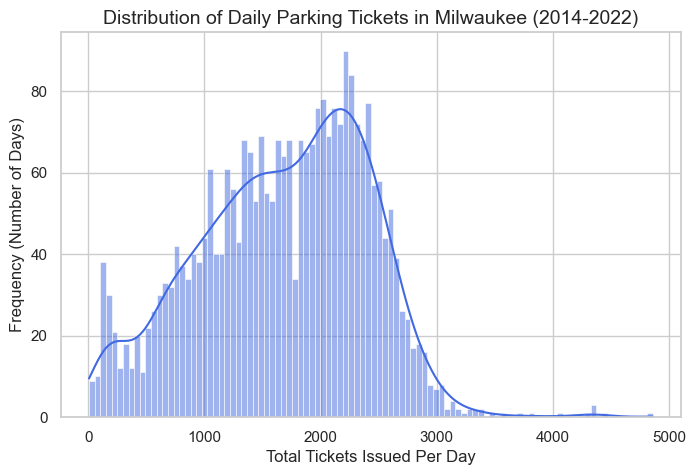

In [12]:
sns.set_theme(style="whitegrid")

# drop the year 2020 and 2021 for the histogram to see if the distribution changes without the covid years (since they are likely outliers in terms of ticket counts)
# daily_summary_no_covid_df = daily_summary_df[~daily_summary_df['Year'].isin([2020, 2021, 2022])]
daily_summary_no_sunday_df = daily_summary_df[~daily_summary_df['WeekDay'].isin(['Sunday'])]

# Histogram Plot of the Distribution of Total Daily Tickets -> show Right Skewed Tail
plt.figure(figsize=(8, 5))
sns.histplot(daily_summary_no_sunday_df['total_tickets'], bins=100, kde=True, color='royalblue')


plt.title("Distribution of Daily Parking Tickets in Milwaukee (2014-2022)", fontsize=14)
plt.xlabel("Total Tickets Issued Per Day", fontsize=12)
plt.ylabel("Frequency (Number of Days)", fontsize=12)
plt.show()

Temporal (Time) Features

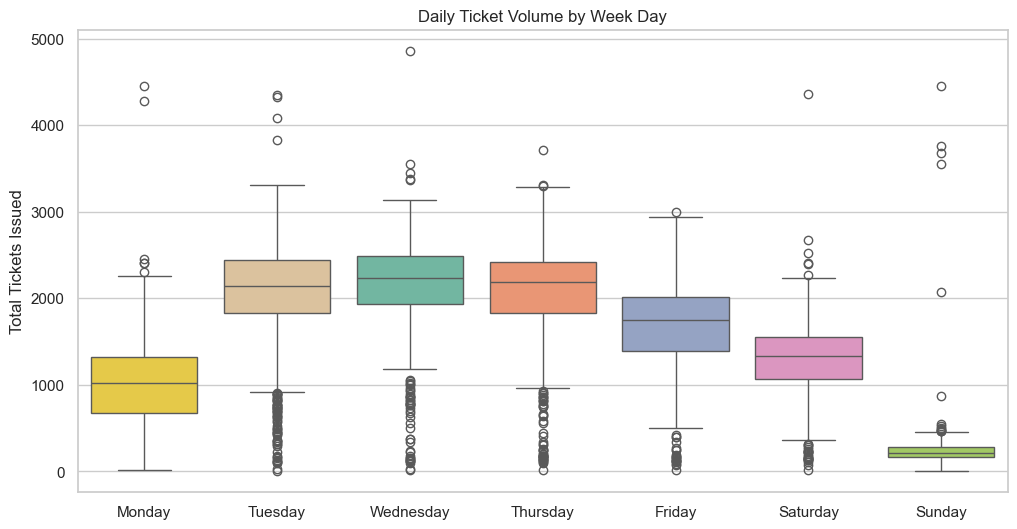

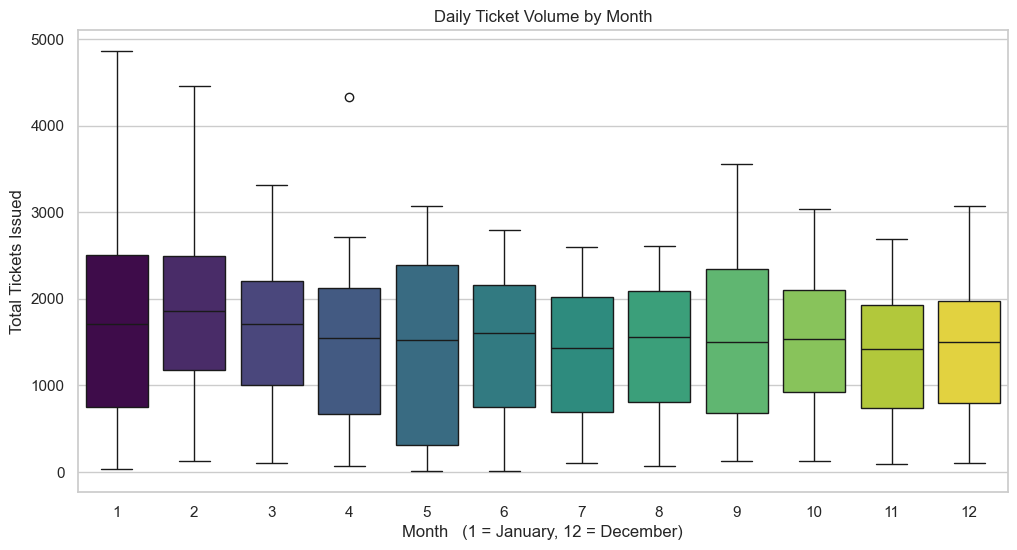

In [13]:
# WeekDay	Year	Month	Day	 is_weekend	is_holiday  
temporal_cols = ['WeekDay', 'Year', 'Month', 'Day', 'is_weekend', 'is_holiday']

# WeekDay vs. Total_Tickets (Daily Count) -> Cat. vs. Num - Boxplot
days_ordered = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12, 6))
sns.boxplot(x='WeekDay', y='total_tickets', order=days_ordered, data=daily_summary_df, hue='WeekDay', palette='Set2')
plt.title("Daily Ticket Volume by Week Day")
plt.xlabel("")
plt.ylabel("Total Tickets Issued")
plt.show()

# Month vs. Total_Tickets
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='total_tickets',  data=daily_summary_df, hue='Month', palette='viridis', legend=False)
plt.title("Daily Ticket Volume by Month")
plt.xlabel("Month   (1 = January, 12 = December)")
plt.ylabel("Total Tickets Issued")
plt.show()


Sunday is very CLEARLY the least Ticketed day, followed by Monday!

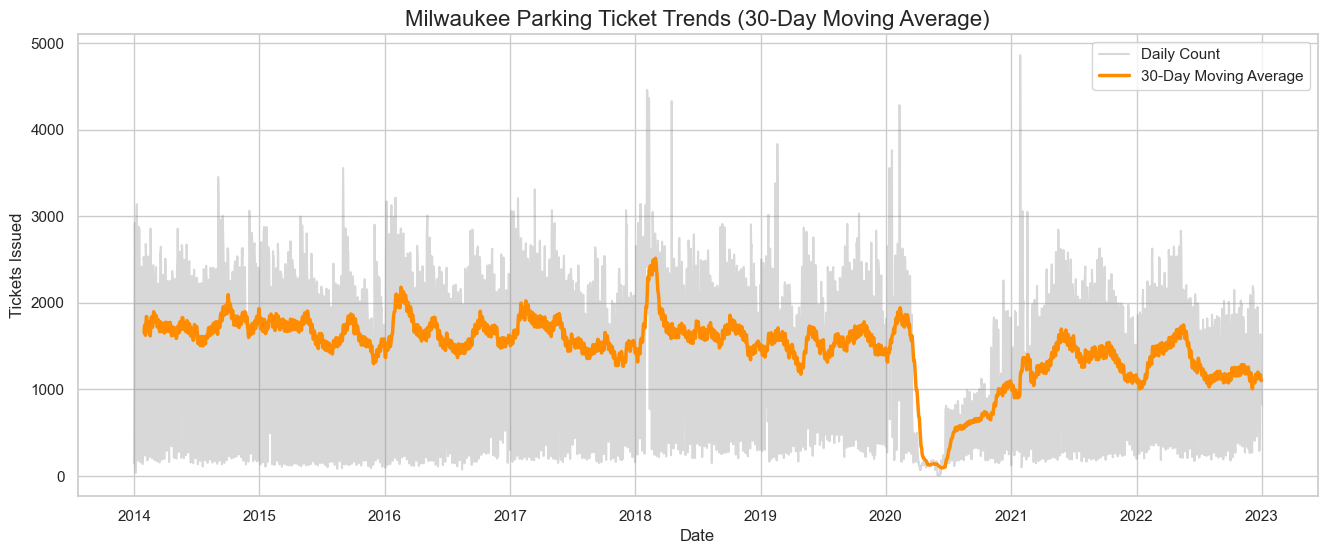

In [14]:
# Dataframe is sorted chronologically
daily_summary_df = daily_summary_df.sort_values('join_date').reset_index(drop=True)

# Calculate the 30-day moving average  [a single day's ticket total and 29 days prior to that Averaged]
daily_summary_df['rolling_30d_avg'] = daily_summary_df['total_tickets'].rolling(window=30).mean()


plt.figure(figsize=(16, 6))
# Plot the noisy daily data lightly in the background
sns.lineplot(data=daily_summary_df, x='join_date', y='total_tickets', color='gray', alpha=0.3, label='Daily Count')

# Plot the smoothed 30-day average boldly on top
sns.lineplot(data=daily_summary_df, x='join_date', y='rolling_30d_avg', color='darkorange', linewidth=2.5, label='30-Day Moving Average')

plt.title("Milwaukee Parking Ticket Trends (30-Day Moving Average)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Tickets Issued")
plt.legend()
plt.show()

In [15]:
# Statistical Testing -- Temporal Features
from scipy.stats import kruskal

print("--- STATISTICAL TESTING: TEMPORAL FEATURES ---")
results = {}

# 1. WeekDay (multi-categorical) vs. Total Tickets [Target] (numerical) -> Kruskal-Wallis test (Bucket of tickets for each weekday)
day_groups = [daily_summary_df[daily_summary_df['WeekDay'] == day]['total_tickets'] for day in days_ordered]
stat, p_val = kruskal(*day_groups)
results["WeekDay_vs_tickets"] = (stat, p_val)

# 2. Month (categorical) vs. Total Tickets (numerical) -> Kruskal-Wallis test
month_groups = [daily_summary_df[daily_summary_df['Month'] == month]['total_tickets'] for month in range(1, 13)]
stat, p_val = kruskal(*month_groups)
results["Month_vs_tickets"] = (stat, p_val)

# 3. Year (categorical) vs. Total Tickets (numerical)
year_groups = [daily_summary_df[daily_summary_df['Year'] == year]['total_tickets'] for year in daily_summary_df['Year'].unique()]
stat, p_val = kruskal(*year_groups)
results["Year_vs_tickets"] = (stat, p_val)

# 4. Day vs. Total Tickets -> Kruskal-Wallis test
day_number_groups = [daily_summary_df[daily_summary_df['Day'] == day]['total_tickets'] for day in range(1, 32)]
stat, p_val = kruskal(*day_number_groups)
results["Day_vs_tickets"] = (stat, p_val)

# print results
for test, (stat, p_val) in results.items():
    print(f"{test}: Kruskal-Wallis H-statistic = {stat:.3f}, p-value = {p_val:.3g}")

from scipy.stats import mannwhitneyu  # binary categorical vs. numerical
binary_results = {}

# 5. is_weekend (binary categorical - 2 groups) vs. Total Tickets (numerical) -> Mann-Whitney U test
weekend_tickets = daily_summary_df[daily_summary_df['is_weekend'] == 1]['total_tickets']
weekday_tickets = daily_summary_df[daily_summary_df['is_weekend'] == 0]['total_tickets']
stat, p_val = mannwhitneyu(weekend_tickets, weekday_tickets)
binary_results["is_weekend_vs_tickets"] = (stat, p_val)

# 6. is_holiday (binary categorical - 2 groups) vs. Total Tickets (numerical) -> Mann-Whitney U test
holiday_tickets = daily_summary_df[daily_summary_df['is_holiday'] == 1]['total_tickets']
not_holiday_tickets = daily_summary_df[daily_summary_df['is_holiday'] == 0]['total_tickets']
stat, p_val = mannwhitneyu(holiday_tickets, not_holiday_tickets)
binary_results["is_holiday_vs_tickets"] = (stat, p_val)

# print results

for test, (stat, p_val) in binary_results.items():
    print(f"{test}: Mann-Whitney statistic = {stat:.3f}, p-value = {p_val:.3g}")

--- STATISTICAL TESTING: TEMPORAL FEATURES ---
WeekDay_vs_tickets: Kruskal-Wallis H-statistic = 1838.493, p-value = 0
Month_vs_tickets: Kruskal-Wallis H-statistic = 61.101, p-value = 5.78e-09
Year_vs_tickets: Kruskal-Wallis H-statistic = 387.142, p-value = 1.05e-78
Day_vs_tickets: Kruskal-Wallis H-statistic = 21.845, p-value = 0.86
is_weekend_vs_tickets: Mann-Whitney statistic = 348076.500, p-value = 7.82e-207
is_holiday_vs_tickets: Mann-Whitney statistic = 129111.000, p-value = 8.79e-21


Violation Sub-Count Features

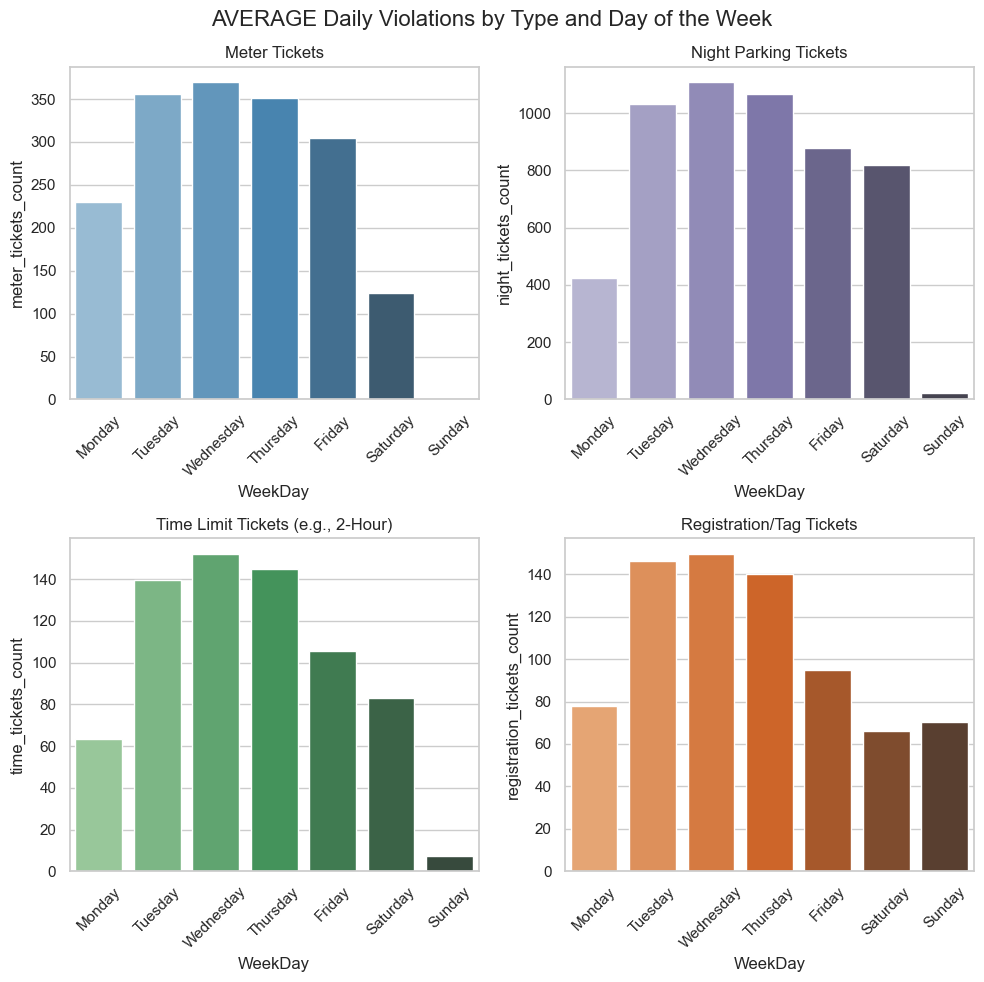

In [16]:
# Group by weekday and calculate the mean (single average number for each day)  for each sub-count
sub_counts = ['meter_tickets_count', 'night_tickets_count', 'time_tickets_count', 'registration_tickets_count']
sub_counts_grouped = daily_summary_df.groupby('WeekDay')[sub_counts].mean().reindex(days_ordered).reset_index()

# Set up the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('AVERAGE Daily Violations by Type and Day of the Week', fontsize=16)

# 1. Meter Tickets
sns.barplot(ax=axes[0, 0], data=sub_counts_grouped, x='WeekDay', y='meter_tickets_count', hue='WeekDay', palette='Blues_d')
axes[0, 0].set_title('Meter Tickets')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Night Tickets
sns.barplot(ax=axes[0, 1], data=sub_counts_grouped, x='WeekDay', y='night_tickets_count', hue='WeekDay', palette='Purples_d')
axes[0, 1].set_title('Night Parking Tickets')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Time Limit Tickets
sns.barplot(ax=axes[1, 0], data=sub_counts_grouped, x='WeekDay', y='time_tickets_count', hue='WeekDay', palette='Greens_d')
axes[1, 0].set_title('Time Limit Tickets (e.g., 2-Hour)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Registration Tickets
sns.barplot(ax=axes[1, 1], data=sub_counts_grouped, x='WeekDay', y='registration_tickets_count', hue='WeekDay', palette='Oranges_d')
axes[1, 1].set_title('Registration/Tag Tickets')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
# Statistical Testing -- Violation subcount Features
# Testing to see if the (Temporal) Day of the Week significantly impacts the volume of these specific ticket violations
from scipy.stats import kruskal

print("--- STATISTICAL TESTING: Temporal Violation Sub-counts [min-targets] by Weekday ---")
results = {}

# meter_tickets_count, night_tickets_count, registration_tickets_count, time_tickets_count
for sub_count_col in sub_counts:
    groups = [daily_summary_df[daily_summary_df['WeekDay'] == day][sub_count_col] for day in days_ordered]
    stat, p_val = kruskal(*groups)
    
    print(f"{sub_count_col}_vs_WeekDay: Kruskal-Wallis H-statistic = {stat:.3f}, p-value = {p_val:.3g}")

--- STATISTICAL TESTING: Temporal Violation Sub-counts [min-targets] by Weekday ---
meter_tickets_count_vs_WeekDay: Kruskal-Wallis H-statistic = 1770.370, p-value = 0
night_tickets_count_vs_WeekDay: Kruskal-Wallis H-statistic = 1547.731, p-value = 0
time_tickets_count_vs_WeekDay: Kruskal-Wallis H-statistic = 1421.070, p-value = 6.64e-304
registration_tickets_count_vs_WeekDay: Kruskal-Wallis H-statistic = 886.000, p-value = 3.99e-188


Weather Features

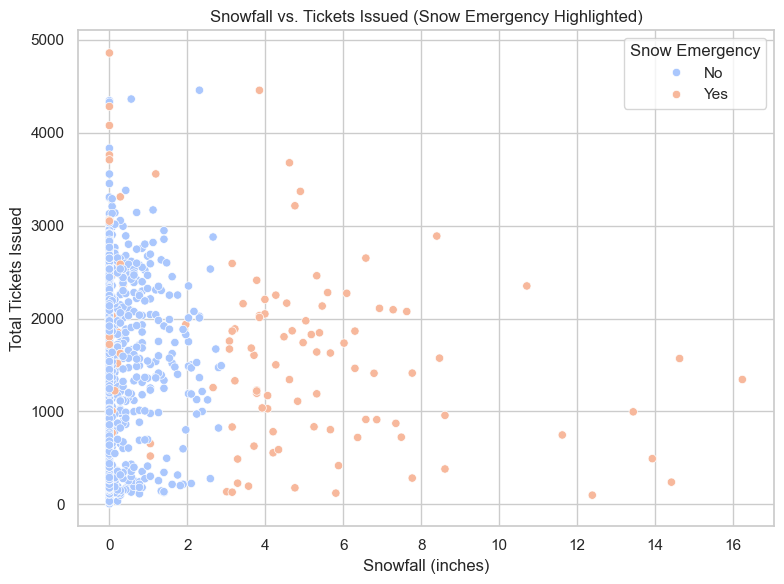

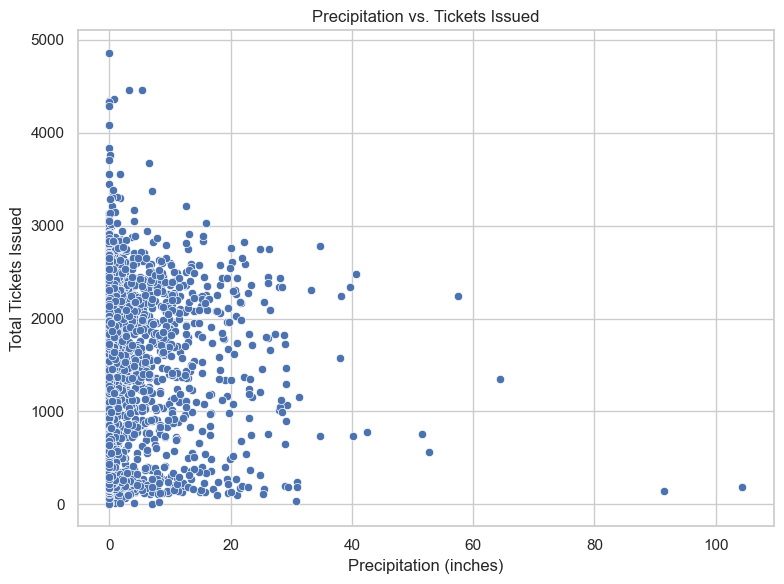

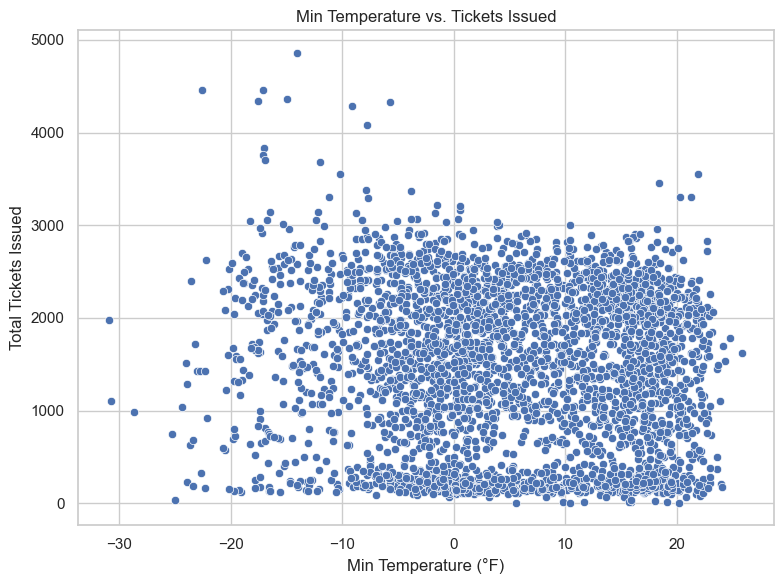

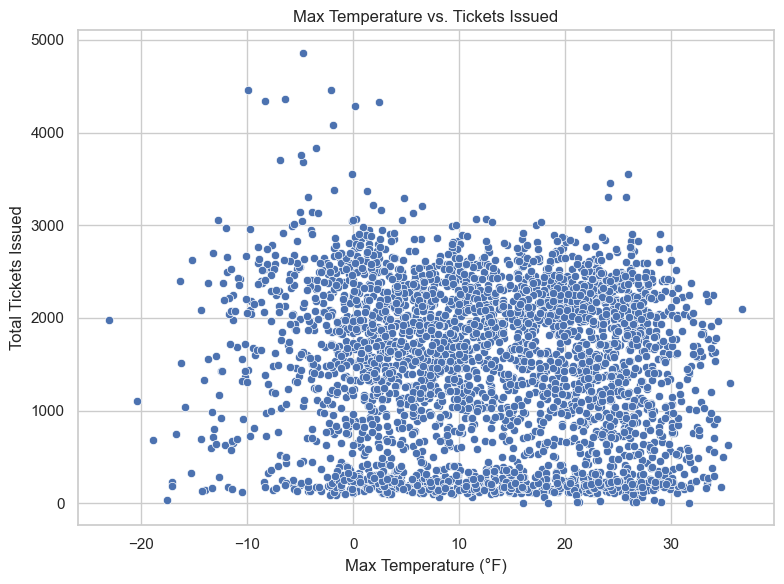

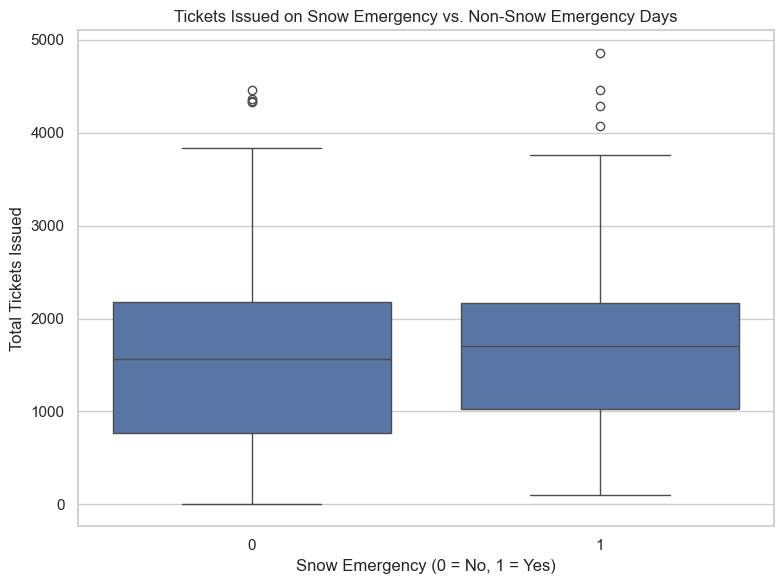

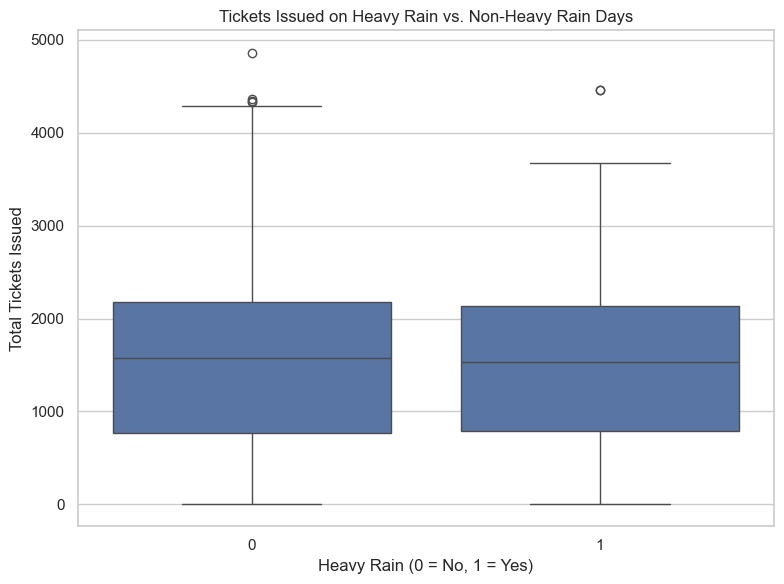

In [18]:
# Weather and tickets issued: separate plots
import matplotlib.pyplot as plt
import seaborn as sns

daily_summary_df = daily_summary_df.copy()
daily_summary_df["snow_emergency_label"] = daily_summary_df["is_snow_emergency"].map({0: "No", 1: "Yes"})

# snowfall vs. tickets issued colored by snow emergency
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=daily_summary_df,
    x="snowfall",
    y="total_tickets",
    hue="snow_emergency_label",
    palette="coolwarm"
)
plt.title("Snowfall vs. Tickets Issued (Snow Emergency Highlighted)")
plt.xlabel("Snowfall (inches)")
plt.ylabel("Total Tickets Issued")
plt.legend(title="Snow Emergency")
plt.tight_layout()
plt.show()

# precipitation vs. tickets issued
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=daily_summary_df,
    x="precipitation",
    y="total_tickets"
)
plt.title("Precipitation vs. Tickets Issued")
plt.xlabel("Precipitation (inches)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

# Min temp vs. tickets issued
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=daily_summary_df,
    x="min_temp",
    y="total_tickets"
)
plt.title("Min Temperature vs. Tickets Issued")
plt.xlabel("Min Temperature (°F)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

# Max temp vs. tickets issued
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=daily_summary_df,
    x="max_temp",
    y="total_tickets"
)
plt.title("Max Temperature vs. Tickets Issued")
plt.xlabel("Max Temperature (°F)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

# is_snow_emergency vs. tickets issued
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=daily_summary_df,
    x="is_snow_emergency",
    y="total_tickets"
)
plt.title("Tickets Issued on Snow Emergency vs. Non-Snow Emergency Days")
plt.xlabel("Snow Emergency (0 = No, 1 = Yes)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

# is_heavy_rain vs. tickets issued
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=daily_summary_df,
    x="is_heavy_rain",
    y="total_tickets"
)
plt.title("Tickets Issued on Heavy Rain vs. Non-Heavy Rain Days")
plt.xlabel("Heavy Rain (0 = No, 1 = Yes)")
plt.ylabel("Total Tickets Issued")
plt.tight_layout()
plt.show()

In [ ]:
# spearman correlations
from scipy.stats import spearmanr

results = {}

# snowfall vs. tickets
corr, pval = spearmanr(daily_summary_df["snowfall"], daily_summary_df["total_tickets"])
results["snowfall_vs_tickets"] = (corr, pval)

# precipitation vs. tickets
corr, pval = spearmanr(daily_summary_df["precipitation"], daily_summary_df["total_tickets"])
results["precipitation_vs_tickets"] = (corr, pval)

# min temp vs. tickets
corr, pval = spearmanr(daily_summary_df["min_temp"], daily_summary_df["total_tickets"])
results["min_temp_vs_tickets"] = (corr, pval)

# max temp vs. tickets
corr, pval = spearmanr(daily_summary_df["max_temp"], daily_summary_df["total_tickets"])
results["max_temp_vs_tickets"] = (corr, pval)

for test, (corr, pval) in results.items():
    print(f"{test}: Spearman correlation = {corr:.3f}, p-value = {pval:.3g}")

    
# chi-squared test for is_snow_emergency vs. total_tickets (categorize total_tickets into bins for chi-squared)
from scipy.stats import chi2_contingency

# create contingency table for is_snow_emergency and binned total_tickets
daily_summary_df["tickets_bin"] = pd.cut(daily_summary_df["total_tickets"], bins=5)
contingency_table = pd.crosstab(daily_summary_df["is_snow_emergency"], daily_summary_df["tickets_bin"])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared test for Snow Emergency vs. Total Tickets (binned): chi2 = {chi2:.3f}, p-value = {p:.3g}")

# chi-squared test for is_heavy_rain vs. total_tickets (categorize total_tickets into bins for chi-squared)
# create contingency table for is_heavy_rain and binned total_tickets
contingency_table = pd.crosstab(daily_summary_df["is_heavy_rain"], daily_summary_df["tickets_bin"])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared test for Heavy Rain vs. Total Tickets (binned): chi2 = {chi2:.3f}, p-value = {p:.3g}")

# chi-squared test for is_snow_emergency_lag1 vs. total_tickets (categorize total_tickets into bins for chi-squared)
# create contingency table for is_snow_emergency_lag1 and binned total_tickets
contingency_table = pd.crosstab(daily_summary_df["is_snow_emergency_lag1"], daily_summary_df["tickets_bin"])
chi2, p, _, _ = chi2_contingency(contingency_table)
print(f"Chi-squared test for Snow Emergency (Lag 1) vs. Total Tickets (binned): chi2 = {chi2:.3f}, p-value = {p:.3g}")

# chi-squared test for is_snow_emergency_lag2 vs. total_tickets (categorize total_tickets into bins for chi-squared)
# create contingency table for is_snow_emergency_lag2 and binned total_tickets
contingency_table = pd.crosstab(daily_summary_df["is_snow_emergency_lag2"], daily_summary_df["tickets_bin"])
chi2, p, _, _ = chi2_contingency(contingency_table)
print(f"Chi-squared test for Snow Emergency (Lag 2) vs. Total Tickets (binned): chi2 = {chi2:.3f}, p-value = {p:.3g}")

snowfall_vs_tickets: Spearman correlation = 0.015, p-value = 0.401
precipitation_vs_tickets: Spearman correlation = -0.009, p-value = 0.625
min_temp_vs_tickets: Spearman correlation = -0.066, p-value = 0.000159
max_temp_vs_tickets: Spearman correlation = -0.093, p-value = 8.39e-08
Chi-squared test for Snow Emergency vs. Total Tickets (binned): chi2 = 62.235, p-value = 9.83e-13
Chi-squared test for Heavy Rain vs. Total Tickets (binned): chi2 = 2.223, p-value = 0.695
Chi-squared test for Snow Emergency (Lag 1) vs. Total Tickets (binned): chi2 = 112.176, p-value = 2.5e-23
Chi-squared test for Snow Emergency (Lag 2) vs. Total Tickets (binned): chi2 = 48.538, p-value = 7.29e-10


#### Co-Linearity Tests (in Categorical and Numerical Features)